# MCMC methods, and when inference falls apart

**Day 2, 15:00 — 30 minutes.** Alexander Fengler.

Everything you fitted this morning and at 14:30 converged quietly. That is
not guaranteed, and the failures teach more than the successes. This session
has two halves:

1. **what MCMC is actually doing** — including writing a sampler from scratch
   in ten lines, so it stops being a black box;
2. **what makes a posterior hard**, on the cognitive model you just fitted.

One idea runs through both. A posterior can be hard because of its **shape**,
and past a certain point no amount of sampler tuning repairs a bad shape —
you have to change the sampler, or change the experiment.

<details class="sbi-note">
<summary>▶️ <b>Running this on Google Colab</b></summary>

The cell below is a no-op on your own machine. On Colab it installs the stack
and downloads the shared helper module, which lives one directory up in the
repository and is therefore not importable there.

Expect the install to take a few minutes. If Colab asks you to restart the
runtime, do it and then run the cell again — the second run is a no-op.

</details>

In [1]:
# --- Google Colab bootstrap; does nothing anywhere else ---------------------
import importlib.util, subprocess, sys, urllib.error, urllib.request

IN_COLAB = importlib.util.find_spec("google.colab") is not None

# `main` once this is merged; the branch is the fallback so the Colab path can
# be tested BEFORE the merge, when main does not yet have these files.
_REFS = ("main", "afengler.tutorials")
_RAW = "https://raw.githubusercontent.com/stefanradev93/sbi4cogsci/{ref}/tutorials/"


def _fetch(module):
    for ref in _REFS:
        try:
            urllib.request.urlretrieve(_RAW.format(ref=ref) + module, module)
            return ref
        except urllib.error.HTTPError:
            continue
    raise RuntimeError(f"could not fetch {module} from any of {_REFS}")


if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pymc>=6.2", "arviz>=1.2", "hssm>=0.4"],
                   check=True)
    for _mod in ["sbi4cogsci_style.py"]:
        print(f"  fetched {_mod} from {_fetch(_mod)}")
    print("Colab setup done.")

In [2]:
import sys, pathlib, warnings, time
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # -> tutorials/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import sbi4cogsci_style as S

S.use()
warnings.filterwarnings("ignore")

RANDOM_SEED = sum(map(ord, "sbi4cogsci-mcmc"))
rng = np.random.default_rng(RANDOM_SEED)

print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 6.2.0 | arviz 1.2.0


## 1. What is MCMC actually trying to do?

We have a distribution $\pi(\theta)$ over some parameter space, and we want
to compute expectations under it:

$$
\mathbb{E}_{\pi}[f] \;=\; \int f(\theta)\, \pi(\theta) \, d\theta .
$$

A posterior mean is $f(\theta) = \theta$; a credible interval is a couple of
quantiles; a posterior predictive is an expectation of the likelihood. All of
them are integrals against $\pi$.

In more than two or three dimensions those integrals are hopeless
analytically and hopeless on a grid. So we give up on computing them and
instead **draw samples** $\theta^{(1)}, \dots, \theta^{(N)} \sim \pi$ and
average:

$$
\mathbb{E}_{\pi}[f] \;\approx\; \frac{1}{N} \sum_{i=1}^{N} f\!\left(\theta^{(i)}\right).
$$

<details class="sbi-note">
<summary>📝 <b><i>&pi;</i> does not have to be a posterior</b></summary>

Nothing above mentions Bayes. MCMC is a general recipe for sampling from *any*
distribution you can evaluate up to a constant — it is used in statistical
physics, combinatorial optimisation and rendering. We happen to point it at
posteriors, and for the first examples below $\pi$ will just be a distribution
we picked because we know the right answer.

</details>

### The normalizing constant, and why we can ignore it

For a posterior, Bayes' rule says

$$
\pi(\theta) \;=\; p(\theta \mid y) \;=\;
\frac{p(y \mid \theta)\, p(\theta)}{p(y)},
\qquad p(y) = \int p(y \mid \theta) p(\theta)\, d\theta .
$$

The numerator is easy: it is the likelihood times the prior, both of which you
wrote down. The denominator $p(y)$ — the **evidence** — is an integral over
the whole parameter space, and it is exactly the kind of integral we just
admitted we cannot do.

The escape is that **every MCMC algorithm only ever looks at ratios**. Write
the unnormalised density as $\tilde{\pi}(\theta) = p(y \mid \theta)p(\theta)$,
so $\pi = \tilde{\pi} / p(y)$. Then for any two points,

$$
\frac{\pi(\theta')}{\pi(\theta)}
\;=\; \frac{\tilde{\pi}(\theta') / p(y)}{\tilde{\pi}(\theta) / p(y)}
\;=\; \frac{\tilde{\pi}(\theta')}{\tilde{\pi}(\theta)} .
$$

**$p(y)$ cancels.** That single cancellation is what makes Bayesian
computation possible at all: you never need the evidence to *sample* the
posterior — only to compare whole models against each other.

## 2. A Metropolis sampler in ten lines

The oldest MCMC algorithm, and still the clearest. From the current point
$\theta$:

1. **propose** a nearby point, $\theta' = \theta + \varepsilon$ with
   $\varepsilon \sim \text{Normal}(0, s^2)$;
2. **accept** it with probability
   $\alpha = \min\!\left(1,\ \tilde{\pi}(\theta')/\tilde{\pi}(\theta)\right)$;
3. if accepted move there, otherwise **stay put and record the current point
   again**.

Because the proposal is symmetric, that ratio is the whole rule. Step 3 is the
part people find strange: rejecting does not mean discarding the iteration, it
means the chain repeats itself — which is how low-density regions end up
visited proportionally *less*, rather than never.

In [3]:
def metropolis(log_target, start, n_steps=100_000, step_size=1.0, seed=0):
    """Random-walk Metropolis. `log_target` need only be correct up to a constant."""
    rng = np.random.default_rng(seed)
    theta = np.atleast_1d(np.asarray(start, dtype=float))
    logp = log_target(theta)
    chain, n_accept = np.empty((n_steps, theta.size)), 0

    for i in range(n_steps):
        proposal = theta + rng.normal(0.0, step_size, theta.size)
        logp_prop = log_target(proposal)
        # accept with probability min(1, pi(prop)/pi(theta)) — in logs
        if np.log(rng.uniform()) < logp_prop - logp:
            theta, logp = proposal, logp_prop
            n_accept += 1
        chain[i] = theta

    return chain, n_accept / n_steps

To show that the normalizing constant genuinely does not matter, target a
distribution written **without** one. This is a Gaussian mixture whose true
density we happen to know, so we can check the answer:

acceptance rate 0.51


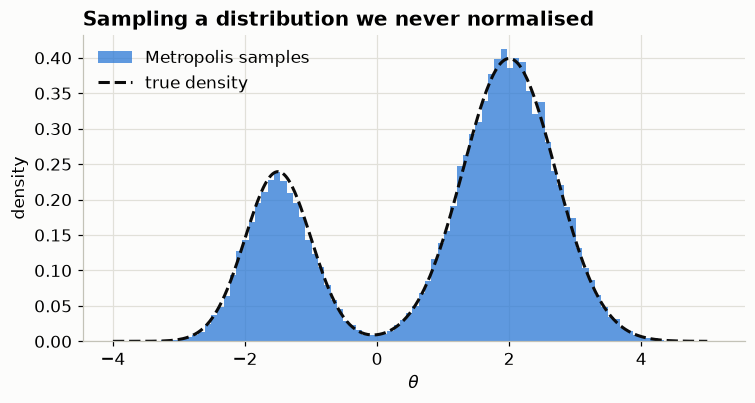

In [4]:
def log_target_mixture(theta):
    """log of an UNNORMALISED two-component mixture. No 1/sqrt(2*pi) anywhere."""
    x = theta[0]
    return np.log(np.exp(-0.5 * ((x - 2.0) / 0.7) ** 2)
                  + 0.6 * np.exp(-0.5 * ((x + 1.5) / 0.5) ** 2))


chain, acc = metropolis(log_target_mixture, start=[0.0], step_size=1.5,
                        n_steps=100_000, seed=RANDOM_SEED)
print(f"acceptance rate {acc:.2f}")

grid = np.linspace(-4, 5, 400)
dens = np.exp([log_target_mixture([g]) for g in grid])
dens /= np.trapezoid(dens, grid)          # normalise only for PLOTTING

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(chain[2000:, 0], bins=90, density=True, color=S.PRIMARY, alpha=0.75,
        label="Metropolis samples")
ax.plot(grid, dens, color=S.TRUTH, ls="--", lw=2, label="true density")
ax.set(title="Sampling a distribution we never normalised",
       xlabel=r"$\theta$", ylabel="density")
ax.legend()
fig.tight_layout()

Twelve lines of Python, no gradients, no library — and the histogram lands on
the density. Note that we **never computed the normalizing constant**; the
sampler only ever saw ratios.

> **Poll.** Our proposal was symmetric: $\theta' = \theta + \text{Normal}(0, s^2)$.
> What breaks if the proposal is *asymmetric* and we keep this same rule?
>
> - **A.** Nothing — the chain still targets $\pi$.
> - **B.** The chain converges to the wrong distribution.
> - **C.** The chain still works but mixes more slowly.
> - **D.** The acceptance rate goes to zero.

<details>
<summary>Answer</summary>

**B.** With an asymmetric proposal you must include the proposal ratio too —
the Metropolis–**Hastings** correction,
$\alpha = \min(1,\ [\tilde{\pi}(\theta')q(\theta \mid \theta')] /
[\tilde{\pi}(\theta)q(\theta' \mid \theta)])$. Omit it and the chain converges
happily to something that is not your target, with no warning. Our symmetric
Gaussian proposal makes $q$ cancel, which is why we could leave it out.

</details>

### The same mixture, pulled apart

That worked because the two modes **overlap**: at $\theta = 0$ the density is
low but not negligible, so a chain crossing the valley is occasionally
accepted. Push the modes apart and keep everything else identical, and the
sampler stops working — completely, and quietly.

In [5]:
def log_target_split(theta):
    """The same two-component mixture, with the modes moved to -6 and +6."""
    x = theta[0]
    return np.log(np.exp(-0.5 * ((x - 6.0) / 0.6) ** 2)
                  + 0.6 * np.exp(-0.5 * ((x + 6.0) / 0.6) ** 2))


# Four chains, TWO started in each mode — the point is what each one does.
starts = [-6.0, -6.0, 6.0, 6.0]
split_chains = np.stack([
    metropolis(log_target_split, [s], n_steps=100_000, step_size=1.5,
               seed=RANDOM_SEED + i)[0][2_000:, 0]
    for i, s in enumerate(starts)])

for i, (s, ch) in enumerate(zip(starts, split_chains)):
    print(f"  chain {i} started at {s:+.0f}:  "
          f"{np.mean(ch > 0):.1%} of its draws in the RIGHT mode")

TRUE_RIGHT_WEIGHT = 1.0 / 1.6         # weights are 1.0 and 0.6
print(f"\npooled estimate of P(right mode) = {np.mean(split_chains > 0):.3f}"
      f"   (truth {TRUE_RIGHT_WEIGHT:.3f})")

  chain 0 started at -6:  0.0% of its draws in the RIGHT mode
  chain 1 started at -6:  0.0% of its draws in the RIGHT mode
  chain 2 started at +6:  100.0% of its draws in the RIGHT mode
  chain 3 started at +6:  100.0% of its draws in the RIGHT mode

pooled estimate of P(right mode) = 0.500   (truth 0.625)


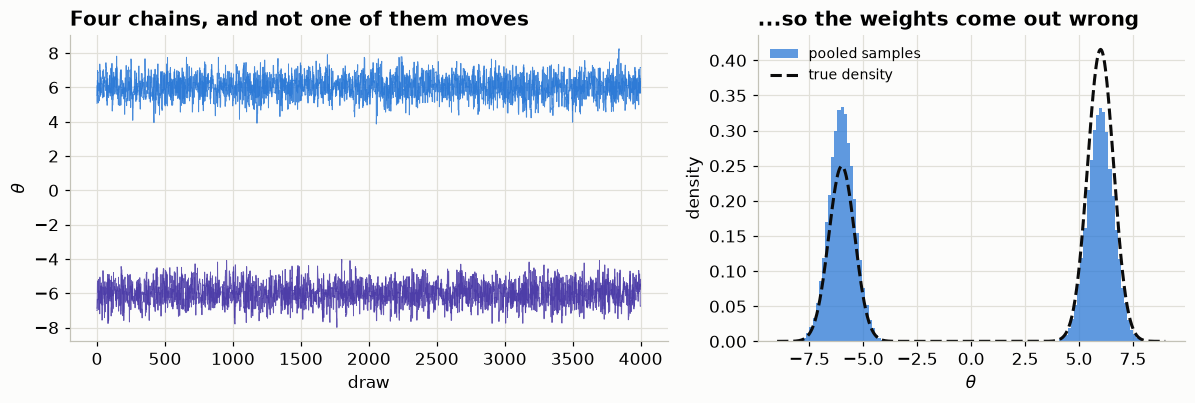

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8),
                         gridspec_kw={"width_ratios": [1.4, 1]})

ax = axes[0]
for i, ch in enumerate(split_chains):
    ax.plot(ch[:4000], lw=0.6, alpha=0.85,
            color=S.PRIMARY if starts[i] > 0 else S.NAIVE)
ax.set(title="Four chains, and not one of them moves",
       xlabel="draw", ylabel=r"$\theta$")

ax = axes[1]
grid_s = np.linspace(-9, 9, 500)
dens_s = np.exp([log_target_split([g]) for g in grid_s])
dens_s /= np.trapezoid(dens_s, grid_s)
ax.hist(split_chains.ravel(), bins=120, density=True, color=S.PRIMARY,
        alpha=0.75, label="pooled samples")
ax.plot(grid_s, dens_s, color=S.TRUTH, ls="--", lw=2, label="true density")
ax.set(title="...so the weights come out wrong", xlabel=r"$\theta$",
       ylabel="density")
ax.legend(fontsize=9)
fig.tight_layout()

Every chain stays in the mode it started in for all 100,000 draws. Each one,
on its own, looks **perfectly healthy**: it is stationary, it mixes briskly
within its mode, and its acceptance rate is fine. Nothing in a single chain
says "there is another mode over there."

Pooling them does not rescue the answer either — it reports the two modes as
equally likely, because we happened to start two chains in each, when the
truth is 0.625 / 0.375. **The estimate is an artifact of where we started.**

In [7]:
dt_split = az.convert_to_datatree({"x": split_chains})
print(f"R-hat = {float(az.rhat(dt_split, var_names=['x']).x):.2f}"
      "     (want < 1.01)")
print(f"ESS   = {float(az.ess(dt_split, var_names=['x']).x):.1f}"
      f"      out of {split_chains.size:,} draws")

R-hat = 1.73     (want < 1.01)
ESS   = 6.0      out of 392,000 draws


<details class="sbi-key" open>
<summary>🔑 <b>R-hat only catches this because the chains disagree</b></summary>

$\hat{R}$ compares the variance *between* chains to the variance *within*
them. Here the between-chain variance is enormous, so it fires loudly.

But notice the precondition: **we started the chains in different places.**
Run four chains from the same initial value and they would all find the same
mode, agree with each other perfectly, and report $\hat{R} \approx 1.00$ for
an answer that is completely wrong. This is the single best argument for
**multiple chains from dispersed starting points**, and it is why PyMC
defaults to four chains with jittered initialisation rather than one.

Gradients do not save you here either. NUTS follows the geometry it is
standing in, and there is no gradient path across a region of zero density —
it is faster and better-behaved than what we wrote, and just as trapped.
Genuinely multimodal posteriors need a different tool: tempering, nested
sampling, or an explicitly enumerated mixture.

</details>

`step_size` is the whole art of a random-walk sampler. Too small and every
proposal is accepted but the chain barely moves; too large and almost
everything is rejected so the chain barely moves. Both failures look like
"high" or "reasonable" acceptance rates.

In [8]:
rows = []
for s in [0.05, 0.5, 1.5, 5.0, 20.0]:
    ch, a = metropolis(log_target_mixture, start=[0.0], step_size=s,
                       n_steps=20_000, seed=RANDOM_SEED)
    x = ch[2000:, 0]
    ess = float(az.ess(az.convert_to_datatree({"x": x[None, :]}),
                       var_names=["x"]).x)
    rows.append({"step_size": s, "acceptance": a, "ESS": ess,
                 "ESS/draw": ess / x.size})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:9.3f}"))

 step_size  acceptance       ESS  ESS/draw
     0.050       0.970    56.313     0.003
     0.500       0.757    71.015     0.004
     1.500       0.505  1125.020     0.063
     5.000       0.258  2437.447     0.135
    20.000       0.072   818.132     0.045


<details class="sbi-key" open>
<summary>🔑 <b>Acceptance rate is not a measure of quality</b></summary>

The smallest step size has by far the **highest** acceptance rate and among
the **worst** ESS — it accepts everything because it proposes almost nothing.
Judge a sampler by effective sample size, never by how often it says yes.

</details>

Notice what that table let us do: we **tuned our way out of trouble**. There
was a bad setting and a good one, we found the good one, and the sampler
worked. Hold on to that, because the next target takes it away.

## 3. When there is no good step size

The mixture was hard in an *easy* way: one knob, and a right answer for it.
Now a target that is much simpler to write down and much harder to sample — a
two-dimensional Gaussian with correlation $\rho$:

$$
\log \tilde{\pi}(x_0, x_1) \;=\;
-\,\frac{x_0^2 - 2\rho\, x_0 x_1 + x_1^2}{2\,(1 - \rho^2)} .
$$

No multimodality, no heavy tails, no awkward constraint. Just an ellipse. As
$\rho \to 1$ that ellipse becomes a long thin ridge along the diagonal, and
that alone is enough to defeat the sampler we just wrote.

In [9]:
def log_target_gaussian(rho):
    """Unnormalised 2-D Gaussian, unit marginals, correlation rho."""
    denom = 2.0 * (1.0 - rho**2)

    def log_target(theta):
        x0, x1 = theta[0], theta[1]
        return -(x0**2 - 2.0 * rho * x0 * x1 + x1**2) / denom

    return log_target


# The ellipse has a long axis along (1, 1) and a short axis along (1, -1).
# Everything below reads more clearly in those coordinates than in x0 / x1.
ALONG = np.array([1.0, 1.0]) / np.sqrt(2.0)      # up the ridge
ACROSS = np.array([1.0, -1.0]) / np.sqrt(2.0)    # across it

RHOS = [0.0, 0.9, 0.99]
for rho in RHOS:
    # the sd along each axis is sqrt(1 +/- rho)
    print(f"rho = {rho:4.2f}:  length {np.sqrt(1 + rho):.3f}   "
          f"width {np.sqrt(1 - rho):.3f}   "
          f"aspect ratio {np.sqrt((1 + rho) / (1 - rho)):6.2f} : 1")

rho = 0.00:  length 1.000   width 1.000   aspect ratio   1.00 : 1
rho = 0.90:  length 1.378   width 0.316   aspect ratio   4.36 : 1
rho = 0.99:  length 1.411   width 0.100   aspect ratio  14.11 : 1


At $\rho = 0.99$ the target is **fourteen times longer than it is wide**. A
random-walk proposal is a *circle* — the same size step in every direction —
and no circle fits a shape like that.

Before measuring anything, watch it happen. Same sampler, same step size, same
number of moves; only $\rho$ changes.

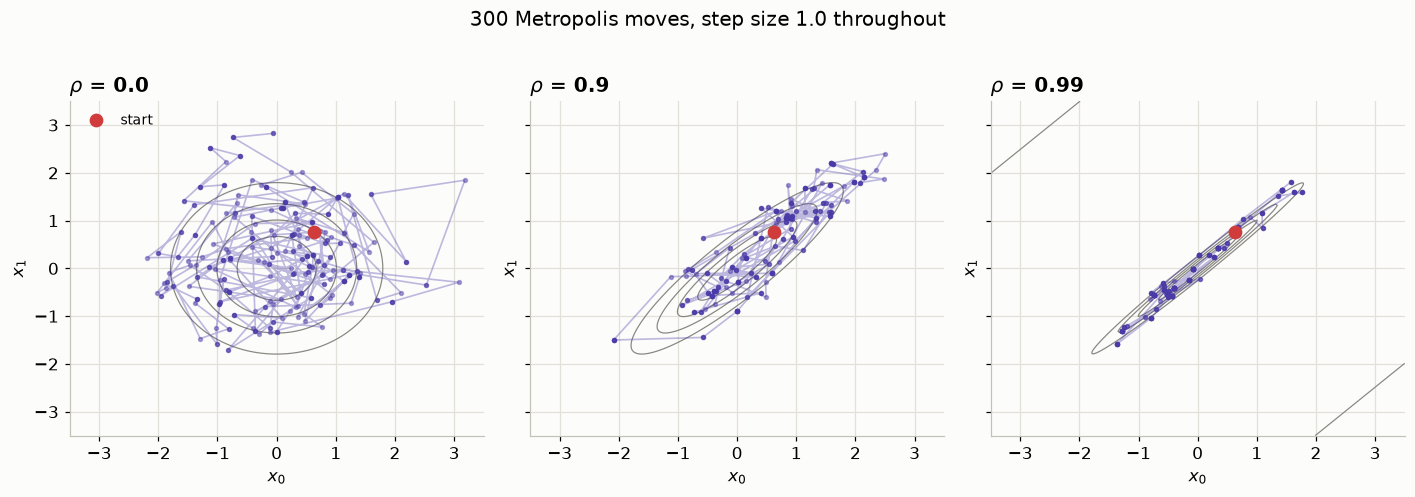

In [10]:
def plot_path(ax, path, rho, title, alpha=0.9):
    """Chain path over the target's contours. Used for every sampler here.

    `alpha` fades the path: a 40-step Gibbs staircase wants to be opaque, a
    300-step scribble wants to be faint or it reads as a solid blob. The start
    marker stays opaque either way — it is a landmark, not part of the trace.
    """
    g = np.linspace(-3.5, 3.5, 200)
    X0, X1 = np.meshgrid(g, g)
    Z = np.exp(-(X0**2 - 2 * rho * X0 * X1 + X1**2) / (2 * (1 - rho**2)))
    ax.contour(X0, X1, Z, levels=5, colors=S.MUTED, linewidths=0.8)
    ax.plot(path[:, 0], path[:, 1], "-", color=S.NAIVE, lw=1.1, alpha=alpha)
    ax.plot(path[:, 0], path[:, 1], "o", color=S.NAIVE, ms=2.5, ls="none",
            alpha=min(1.0, alpha + 0.1))
    ax.plot(path[0, 0], path[0, 1], "o", color=S.DIVERGENT, ms=8, label="start")
    ax.set(title=title, xlabel="$x_0$", ylabel="$x_1$",
           xlim=(-3.5, 3.5), ylim=(-3.5, 3.5))


N_SHOW = 300
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4), sharex=True, sharey=True)
for ax, rho in zip(axes, RHOS):
    path, _ = metropolis(log_target_gaussian(rho), start=[0.0, 0.0],
                         n_steps=N_SHOW, step_size=1.0, seed=RANDOM_SEED)
    ax.plot([], [])
    plot_path(ax, path, rho, rf"$\rho$ = {rho}", alpha=0.35)
axes[0].legend(fontsize=9, loc="upper left")
fig.suptitle(f"{N_SHOW} Metropolis moves, step size 1.0 throughout", y=1.02)
fig.tight_layout()

Read those left to right. At $\rho = 0$ the chain wanders freely over the
whole target. At $\rho = 0.99$ it is pinned inside a thin diagonal sliver and
barely travels its length — the same 300 moves cover a small fraction of the
distribution. The proposal has not changed; only the shape it is trying to
explore has.

Now put a number on that.

In [11]:
def run_chains(log_target, step_size, n_chains=4, n_steps=25_000, warmup=5_000):
    """Several independent chains, so an ESS estimate is not one seed's luck."""
    kept, accs = [], []
    for c in range(n_chains):
        ch, a = metropolis(log_target, start=[0.0, 0.0], n_steps=n_steps,
                           step_size=step_size, seed=RANDOM_SEED + c)
        kept.append(ch[warmup:])
        accs.append(a)
    return np.stack(kept), float(np.mean(accs))     # (chain, draw, 2)


def ess_per_draw(chains, direction):
    """ESS as a fraction of draws, for the projection onto `direction`."""
    projected = chains @ direction                   # (chain, draw)
    dt = az.convert_to_datatree({"x": projected})
    return float(az.ess(dt, var_names=["x"]).x) / projected.size


STEPS = [0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 4.0]
sweep = []
for rho in RHOS:
    lt = log_target_gaussian(rho)
    for s in STEPS:
        chains, acc = run_chains(lt, s)
        sweep.append({"rho": rho, "step_size": s, "acceptance": acc,
                      "ESS/draw along": ess_per_draw(chains, ALONG),
                      "ESS/draw across": ess_per_draw(chains, ACROSS)})
sweep = pd.DataFrame(sweep)

for rho in RHOS:
    print(f"\n--- rho = {rho} " + "-" * 46)
    print(sweep[sweep.rho == rho].drop(columns="rho")
          .to_string(index=False, float_format=lambda v: f"{v:10.4f}"))


--- rho = 0.0 ----------------------------------------------
 step_size  acceptance  ESS/draw along  ESS/draw across
    0.0500      0.9751          0.0004           0.0003
    0.1000      0.9500          0.0022           0.0019
    0.2500      0.8771          0.0133           0.0143
    0.5000      0.7592          0.0401           0.0410
    1.0000      0.5539          0.0972           0.1051
    2.0000      0.2928          0.1247           0.1314
    4.0000      0.1067          0.0662           0.0620

--- rho = 0.9 ----------------------------------------------
 step_size  acceptance  ESS/draw along  ESS/draw across
    0.0500      0.9476          0.0002           0.0061
    0.1000      0.8950          0.0008           0.0210
    0.2500      0.7466          0.0065           0.0944
    0.5000      0.5462          0.0174           0.1884
    1.0000      0.3133          0.0337           0.1827
    2.0000      0.1381          0.0413           0.0904
    4.0000      0.0480          0.02

### The squeeze

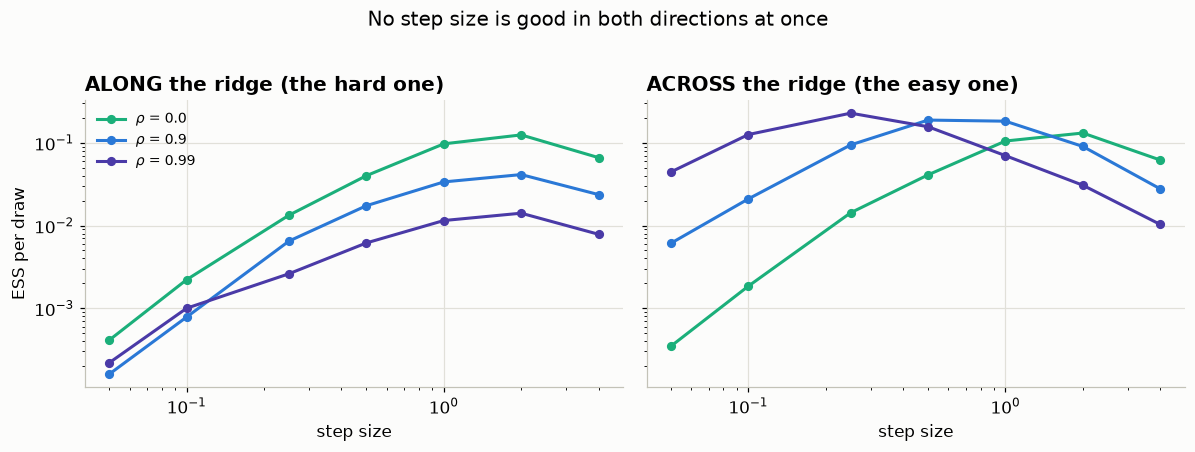

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, direction, name in [(axes[0], "along", "ALONG the ridge (the hard one)"),
                            (axes[1], "across", "ACROSS the ridge (the easy one)")]:
    for rho, colour in zip(RHOS, [S.ALT, S.PRIMARY, S.NAIVE]):
        block = sweep[sweep.rho == rho]
        ax.plot(block["step_size"], block[f"ESS/draw {direction}"], "o-",
                color=colour, label=f"$\\rho$ = {rho}")
    ax.set(xscale="log", yscale="log", xlabel="step size", title=name)
axes[0].set_ylabel("ESS per draw")
axes[0].legend(fontsize=9)
fig.suptitle("No step size is good in both directions at once", y=1.02)
fig.tight_layout()

In [13]:
worst = sweep[sweep.rho == 0.99]
best_along = worst.loc[worst["ESS/draw along"].idxmax()]
best_across = worst.loc[worst["ESS/draw across"].idxmax()]
uncorrelated = sweep[sweep.rho == 0.0]["ESS/draw along"].max()

print("at rho = 0.99:")
print(f"  best step size ALONG  the ridge: {best_along['step_size']:5.2f}"
      f"   (ESS/draw {best_along['ESS/draw along']:.4f})")
print(f"  best step size ACROSS the ridge: {best_across['step_size']:5.2f}"
      f"   (ESS/draw {best_across['ESS/draw across']:.4f})")
print("  -> the two directions want DIFFERENT step sizes, and you get one.\n")
print(f"  best achievable along the ridge : {best_along['ESS/draw along']:.4f}")
print(f"  best achievable when rho = 0    : {uncorrelated:.4f}")
print(f"  -> even at its own optimum, "
      f"{uncorrelated / best_along['ESS/draw along']:.0f}x worse than "
      "the uncorrelated target.")

at rho = 0.99:
  best step size ALONG  the ridge:  2.00   (ESS/draw 0.0141)
  best step size ACROSS the ridge:  0.25   (ESS/draw 0.2285)
  -> the two directions want DIFFERENT step sizes, and you get one.

  best achievable along the ridge : 0.0141
  best achievable when rho = 0    : 0.1247
  -> even at its own optimum, 9x worse than the uncorrelated target.


That is the difference from the mixture. There, tuning *worked* — there was a
good step size and it was genuinely good. Here every step size is bad, in one
of two ways:

- **small steps** stay inside the narrow width, so they are almost always
  accepted, and they crawl along a ridge fourteen times longer than it is wide;
- **large steps** are big enough to travel the ridge, but a *circular* step
  that large mostly lands off the ridge sideways, and is rejected.

The two failures meet in a flat, mediocre middle. There is no knife-edge
setting you might have missed — the whole range is poor, and the best of it is
an order of magnitude below what the same sampler achieves on a round target.

<details class="sbi-warn" open>
<summary>⚠️ <b>A correct-looking answer from a chain that did not work</b></summary>

The most dangerous cell in that table is the small-step one, because of what
it reports about itself. Run it and look:

</details>

In [14]:
chains_bad, acc_bad = run_chains(log_target_gaussian(0.99), step_size=0.05)
n_draws = chains_bad[..., 0].size
ess_bad = ess_per_draw(chains_bad, ALONG)

print(f"step_size 0.05, rho 0.99:  acceptance {acc_bad:.1%}")
print(f"  sd(x0) pooled over chains = {chains_bad[..., 0].std():.3f}"
      "   (the truth is exactly 1.000)")
print(f"  ESS/draw along the ridge  = {ess_bad:.5f}")
print(f"  -> about {ess_bad * n_draws:.0f} independent draws out of {n_draws:,}\n")

# The same quantity, chain by chain — and where each chain ended up.
along_bad = chains_bad @ ALONG
for c in range(along_bad.shape[0]):
    print(f"  chain {c}: mean along the ridge {along_bad[c].mean():+.2f}, "
          f"sd {along_bad[c].std():.2f}   (true sd {np.sqrt(1 + 0.99):.2f})")

step_size 0.05, rho 0.99:  acceptance 84.4%
  sd(x0) pooled over chains = 0.967   (the truth is exactly 1.000)
  ESS/draw along the ridge  = 0.00022
  -> about 18 independent draws out of 80,000

  chain 0: mean along the ridge +0.70, sd 1.20   (true sd 1.41)
  chain 1: mean along the ridge -0.07, sd 1.67   (true sd 1.41)
  chain 2: mean along the ridge +0.61, sd 1.17   (true sd 1.41)
  chain 3: mean along the ridge +0.18, sd 1.22   (true sd 1.41)


A marginal standard deviation in the right neighbourhood is **not** evidence
that the chain worked. This one lands within a few percent of the truth while
containing a couple of dozen genuinely independent draws.

And look at *why* it lands there, because the reason is not the comforting
one. At $\rho = 0.99$ the variance of $x_0$ is **99.5% the along-the-ridge
direction** — the hard one — since $\operatorname{Var} = (1+\rho)/2$ along
against $(1-\rho)/2$ across. So the marginal that came out right is precisely
the direction the chain could not explore.

The per-chain numbers show the trick. Not one of the four gets the width
right, and they do not even err in the same direction — three are too narrow
because they only saw part of the ridge, one is too wide. Their *means* also
sit at different points along the ridge, and that between-chain scatter refills
roughly the variance the narrow ones are missing. Pooling manufactures a
plausible number out of four separately wrong ones.

Which is the argument for doing both: pool several chains **and** check
$\hat{R}$, which is what notices that the chains disagree. Do not eyeball
whether a summary looks plausible.

## 4. The same target, in PyMC

Two things are worth showing here. First, **PyMC gives you Metropolis too**,
one argument away. It is not quite the sampler we wrote: for a vector-valued
variable `pm.Metropolis` updates **one coordinate at a time**, with its own
accept/reject for each — the coordinate-wise cousin of our blocked proposal.
Hold that thought; section 5 is about what axis-aligned moves cost you.
Second, and the reason this section exists: **NUTS crosses this target
without being tuned at all.**

In [15]:
def gaussian_pymc_model(rho):
    """A PyMC model whose posterior IS the correlated Gaussian — no data needed."""
    cov = np.array([[1.0, rho], [rho, 1.0]])
    with pm.Model() as model:
        pm.MvNormal("x", mu=np.zeros(2), cov=cov, shape=2)
    return model


# `step=` picks the sampler. `pm.Metropolis()` must be constructed INSIDE the
# model context — outside it you get "TypeError: No model on context stack".
with gaussian_pymc_model(0.99):
    idata_mh = pm.sample(draws=2000, tune=2000, chains=2, cores=1,
                         step=pm.Metropolis(), progressbar=False,
                         random_seed=RANDOM_SEED)

print("Metropolis:")
print(az.summary(idata_mh, kind="diagnostics").to_string())

Sequential sampling (2 chains in 1 job)


Metropolis: [x]


Sampling 2 chains for 2_000 tune and 2_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Metropolis:
      ess_bulk  ess_tail r_hat mcse_mean mcse_sd
x[0]         8         7  1.24      0.34    0.28
x[1]         8         7  1.24      0.34    0.28


`ess_bulk` in the single digits, and $\hat{R}$ far past the 1.01 threshold —
out of 4000 draws. PyMC prints warnings saying exactly this. Same model, same
budget, NUTS:

In [16]:
with gaussian_pymc_model(0.99):
    idata_nuts = pm.sample(draws=2000, tune=2000, chains=2, cores=1,
                           nuts_sampler="pymc", progressbar=False,
                           random_seed=RANDOM_SEED)

print("NUTS:")
print(az.summary(idata_nuts, kind="diagnostics").to_string())

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [x]


Sampling 2 chains for 2_000 tune and 2_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


NUTS:
      ess_bulk  ess_tail r_hat mcse_mean mcse_sd
x[0]       703       868  1.00     0.037   0.026
x[1]       684       892  1.00     0.037   0.026


The same two chains as paths, drawn exactly as before — so this is directly
comparable to the hand-written sampler above and to Gibbs below. These are
post-warmup draws, so both start somewhere sensible; the question is where
they go from there.

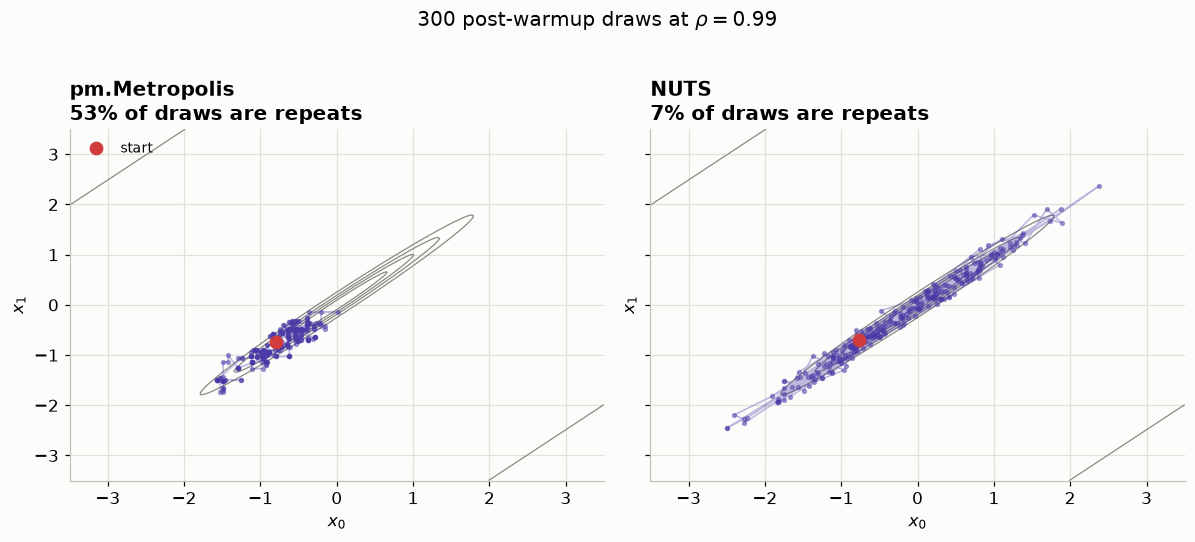

In [17]:
N_SHOW_PYMC = 300
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharex=True, sharey=True)
for ax, (name, idt) in zip(axes, [("pm.Metropolis", idata_mh), ("NUTS", idata_nuts)]):
    path = idt.posterior.dataset["x"].values[0][:N_SHOW_PYMC]     # chain 0
    # A rejected proposal repeats the current point, so an "exactly repeated"
    # draw is a wasted iteration. NUTS has none: every draw is a new point.
    repeated = np.mean(np.all(np.diff(path, axis=0) == 0, axis=1))
    plot_path(ax, path, 0.99, f"{name}\n{repeated:.0%} of draws are repeats",
              alpha=0.35)
axes[0].legend(fontsize=9, loc="upper left")
fig.suptitle(f"{N_SHOW_PYMC} post-warmup draws at $\\rho = 0.99$", y=1.02)
fig.tight_layout()

`pm.Metropolis` barely leaves the neighbourhood it started in, and **over half
its draws are exact repeats** — rejected proposals, recorded again. NUTS
repeats a small fraction of the time and otherwise lands somewhere new, far
up or down the ridge rather than inching along it. In the same 300 draws it
covers the whole target while Metropolis covers a corner of it.

That is what a gradient buys. NUTS follows the *shape* of the target instead of
guessing at it, so the ridge stops being an obstacle and becomes a direction to
travel in.

In [18]:
n_steps_mean = float(idata_nuts["sample_stats"].dataset["n_steps"].mean())
print(f"NUTS leapfrog steps per draw at rho = 0.99: {n_steps_mean:.1f}")
print("  (Metropolis has no analogue — it takes one cheap step and rejects it.)")

NUTS leapfrog steps per draw at rho = 0.99: 12.4
  (Metropolis has no analogue — it takes one cheap step and rejects it.)


It is not free, though: those long jumps cost **many gradient evaluations per
draw**, and that count climbs as the geometry worsens.

That is the trade you want: ill-conditioning turns into a **larger bill**
rather than into a confident wrong number. Metropolis, on the same target,
stayed cheap and reported a posterior it had not actually explored.

## 5. *Advanced:* Gibbs has the same problem, for a different reason

*(Skip if we are short on time — nothing later depends on it.)*

You might reasonably suspect the trouble was our clumsy tuning. So take tuning
off the table completely.

For this Gaussian the **conditional** distributions are known in closed form:

$$
x_0 \mid x_1 \;\sim\; \text{Normal}\!\left(\rho\, x_1,\ \sqrt{1-\rho^2}\right),
$$

and symmetrically. A **Gibbs sampler** simply alternates: draw $x_0$ given
$x_1$, then $x_1$ given the new $x_0$. There is no step size, no proposal and
**no rejection** — every draw is exact and every draw is accepted.

In [19]:
def gibbs(rho, n_steps=25_000, seed=RANDOM_SEED, record_path=False):
    """Coordinate-wise Gibbs. Nothing to tune; acceptance is 1 by construction."""
    rng_g = np.random.default_rng(seed)
    sd = np.sqrt(1.0 - rho**2)
    x = np.zeros(2)
    chain = np.empty((n_steps, 2))
    path = [x.copy()]

    for i in range(n_steps):
        x[0] = rng_g.normal(rho * x[1], sd)      # x0 | x1
        if record_path:
            path.append(x.copy())
        x[1] = rng_g.normal(rho * x[0], sd)      # x1 | x0
        if record_path:
            path.append(x.copy())
        chain[i] = x

    return (chain, np.array(path)) if record_path else chain


gibbs_chains = {rho: np.stack([gibbs(rho, seed=RANDOM_SEED + c)[5_000:]
                               for c in range(4)])
                for rho in RHOS}

# For this target Gibbs turns each coordinate into an AR(1) process with lag-1
# correlation exactly rho^2 — so a sampler with NO knobs and a 100% acceptance
# rate is still provably slow here, by an amount you can write down in advance.
print(f"at rho = 0.99, Gibbs ESS/draw:  "
      f"ACROSS the ridge {ess_per_draw(gibbs_chains[0.99], ACROSS):.3f}   "
      f"ALONG it {ess_per_draw(gibbs_chains[0.99], ALONG):.4f}")

at rho = 0.99, Gibbs ESS/draw:  ACROSS the ridge 1.016   ALONG it 0.0110


Excellent in one direction, hopeless in the other — and no setting exists
that would trade one for the other, because there is no setting.

The picture shows why:

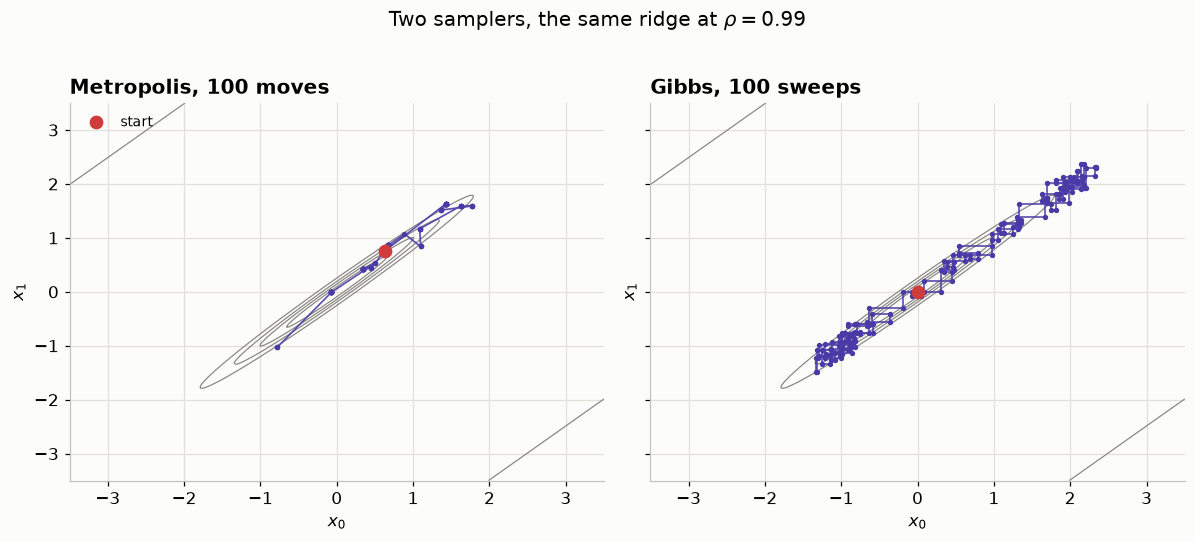

In [20]:
# Same helper as the Metropolis paths above, so the two are directly comparable.
_, path_gibbs = gibbs(0.99, n_steps=100, seed=RANDOM_SEED, record_path=True)
path_mh, _ = metropolis(log_target_gaussian(0.99), start=[0.0, 0.0],
                        n_steps=100, step_size=1.0, seed=RANDOM_SEED)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharex=True, sharey=True)
plot_path(axes[0], path_mh, 0.99, r"Metropolis, 100 moves")
plot_path(axes[1], path_gibbs, 0.99, r"Gibbs, 100 sweeps")
axes[0].legend(fontsize=9, loc="upper left")
fig.suptitle(r"Two samplers, the same ridge at $\rho = 0.99$", y=1.02)
fig.tight_layout()

Every move is **horizontal or vertical**, because every move updates one
coordinate. The ridge runs at 45°. So the chain can only climb it as a
staircase of tiny right-angled steps, each limited by the *width* of the ridge
rather than by its length. Nothing here is tunable: the constraint is the
**coordinate system**, not the step length.

<details class="sbi-note">
<summary>📝 <b>Two very different algorithms, one ellipse</b></summary>

Gibbs has nothing to tune and rejects nothing, and it is still two orders of
magnitude short of independent sampling along the ridge. That is what tells
you the problem was never the algorithm.

One connection worth noticing: `pm.Metropolis()` from the previous section
also updates a vector one coordinate at a time, so its moves are
axis-aligned too and it inherits precisely this weakness.

</details>

## 6. When the problem is the *posterior*, not the sampler

Everything so far used a target we invented, with a correlation we chose. Now
the cognitive model — where the same geometry shows up without anyone asking
for it, and where you cannot fix it by changing sampler.

At 14:30 everything recovered cleanly. Here are two datasets from the **same**
DDM, differing only in drift rate — and therefore in how often the participant
makes an error.

In [21]:
from hssm.likelihoods import DDM
from ssms import Simulator

DRAWS, TUNE, CHAINS = 700, 700, 2
# z = 0.65 puts the start point above the midpoint, so the process begins nearer
# the "+1" boundary. That asymmetry is what makes the geometry legible later.
# v_balanced is set to land the error rate inside the 15-35% band that the
# design literature recommends — with a biased start point that takes a smaller
# drift than you might expect.
TRUE = {"v_balanced": 0.2, "v_extreme": 3.0, "a": 1.2, "z": 0.65, "t": 0.3}
PARAMS = ["v", "a", "z", "t"]


def make(v_true, n=600):
    o = Simulator(model="ddm").simulate(theta=[v_true, TRUE["a"], TRUE["z"], TRUE["t"]],
                                        n_samples=n, random_state=RANDOM_SEED)
    return np.column_stack([o["rts"].flatten(), o["choices"].flatten()])


def fit_ddm(observed, seed=RANDOM_SEED):
    with pm.Model():
        v = pm.Normal("v", 0.0, 3.0)
        a = pm.HalfNormal("a", 2.0)
        z = pm.Beta("z", 5.0, 5.0)
        t = pm.HalfNormal("t", 0.5)
        DDM("obs", v=v, a=a, z=z, t=t, observed=observed)
        # `initvals` is load-bearing, for the reason given in the 14:30 session:
        # PyMC would otherwise start `t` at 0.5, above the fastest RT in both of
        # these datasets (0.351 / 0.353). Beyond that point the DDM
        # log-likelihood is a flat constant, so a chain landing there has no
        # gradient to follow back and never recovers.
        return pm.sample(draws=DRAWS, tune=TUNE, chains=CHAINS, cores=1,
                         nuts_sampler="pymc", progressbar=False, random_seed=seed,
                         initvals={"t": np.array(0.1)})


fits, posteriors, error_rates = {}, {}, {}
for label, v_true in [("balanced", TRUE["v_balanced"]), ("extreme", TRUE["v_extreme"])]:
    obs = make(v_true)
    error_rates[label] = (obs[:, 1] == -1).mean()
    idata = fit_ddm(obs)
    fits[label] = idata
    p = idata.posterior.dataset
    posteriors[label] = {k: p[k].values.ravel() for k in PARAMS}
    print(f"{label:9s} error rate {error_rates[label]:5.1%}   "
          + "  ".join(f"{k}={posteriors[label][k].mean():5.2f}" for k in PARAMS))
print(f"\ntruth: v={TRUE['v_balanced']} or {TRUE['v_extreme']}, a={TRUE['a']}, "
      f"z={TRUE['z']}, t={TRUE['t']}")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [v, a, z, t]


Sampling 2 chains for 700 tune and 700 draw iterations (1_400 + 1_400 draws total) took 5 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Sequential sampling (2 chains in 1 job)


NUTS: [v, a, z, t]


Sampling 2 chains for 700 tune and 700 draw iterations (1_400 + 1_400 draws total) took 16 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


extreme   error rate  0.0%   v= 3.41  a= 1.42  z= 0.61  t= 0.28

truth: v=0.2 or 3.0, a=1.2, z=0.65, t=0.3


### The correlation structure is the diagnosis

Text(0.5, 1.02, 'Every parameter pair, both designs')

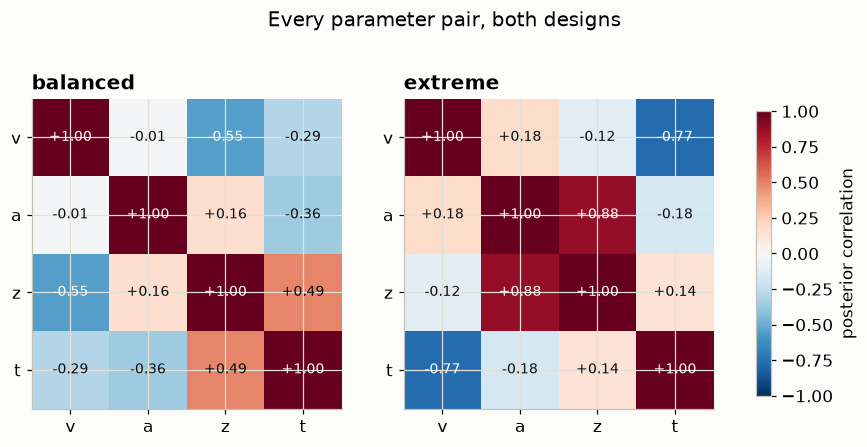

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, label in zip(axes, ["balanced", "extreme"]):
    d = posteriors[label]
    M = np.array([[np.corrcoef(d[i], d[j])[0, 1] for j in PARAMS] for i in PARAMS])
    im = ax.imshow(M, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set(xticks=range(4), yticks=range(4), title=label)
    ax.set_xticklabels(PARAMS); ax.set_yticklabels(PARAMS)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{M[i, j]:+.2f}", ha="center", va="center", fontsize=9,
                    color="white" if abs(M[i, j]) > 0.55 else S.TRUTH)
fig.colorbar(im, ax=axes, shrink=0.8, label="posterior correlation")
fig.suptitle("Every parameter pair, both designs", y=1.02)

In the balanced design the correlations are moderate and *structured*. In the
extreme design one pair dominates everything else: `a` with `z`, at +0.88.

The strongest pair in the extreme design is **`a` with `z`** — boundary
separation against start point — and the *weakest* is `v` with `a`. That is
worth pausing on, because `v`–`a` is the pair people reach for first.

### For the extreme data `a` and `z` collapse together

With essentially no errors, every single trial ended at the **same** boundary.
So ask what the data can possibly measure. The process starts at $z\,a$ and
has to travel


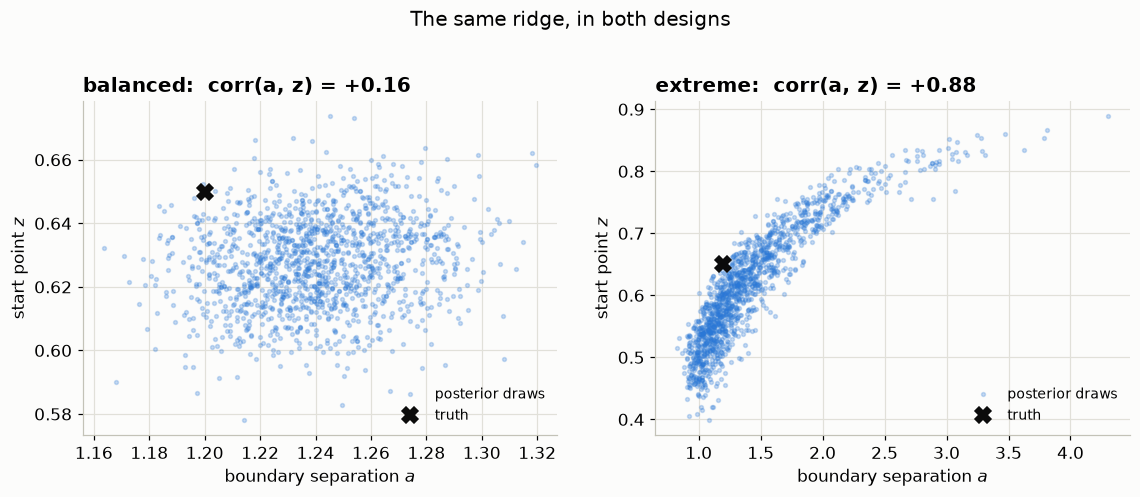

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))
for col, label in enumerate(["balanced", "extreme"]):
    d = posteriors[label]

    ax = axes[col]
    r = np.corrcoef(d["a"], d["z"])[0, 1]
    ax.plot(d["a"], d["z"], "o", color=S.PRIMARY, ms=2.5, alpha=0.25, ls="none",
            label="posterior draws")
    S.truth_point(ax, TRUE["a"], TRUE["z"])
    ax.set(title=f"{label}:  corr(a, z) = {r:+.2f}",
           xlabel="boundary separation $a$", ylabel="start point $z$")
    ax.legend(loc="lower right", fontsize=9)

fig.suptitle("The same ridge, in both designs", y=1.02)
fig.tight_layout()

Left: a compact blob sitting on the truth. Right: a long thin ridge. The
truth is on that ridge — but so is every other point along it, and the data
have no way to say which.

### All of it at once

`a`–`z` is the worst pair, but it is not the only one. The full pair plot
shows every two-parameter view **and** the marginals down the diagonal — and
the relationship between those two things is the point.

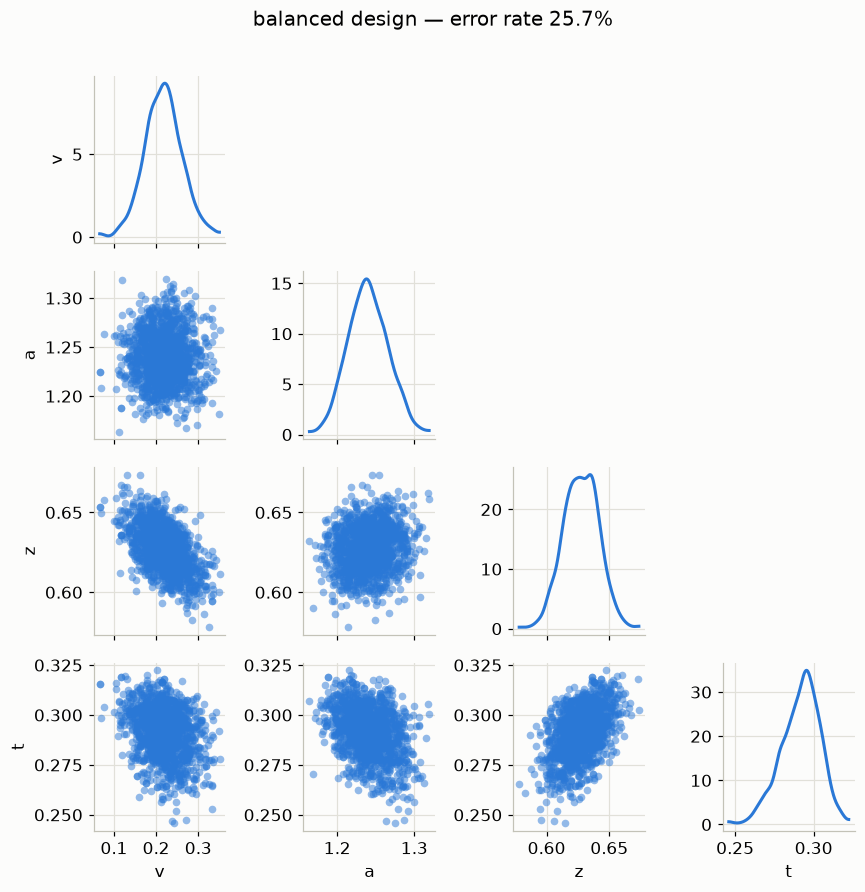

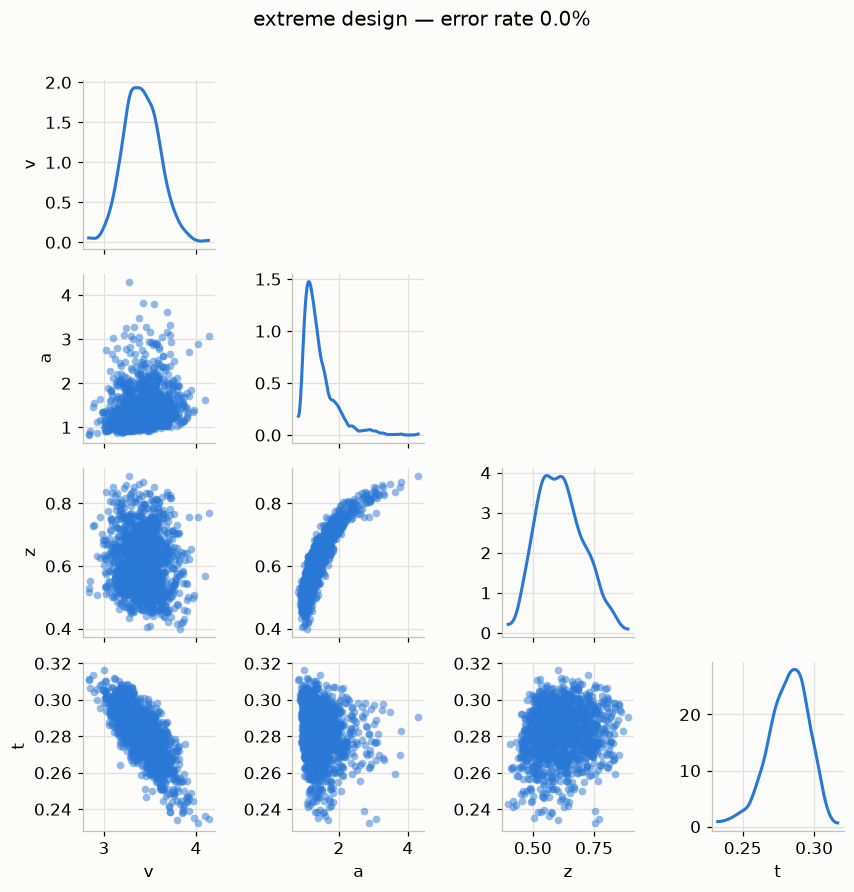

In [24]:
for label in ["balanced", "extreme"]:
    az.plot_pair(fits[label], var_names=PARAMS, marginal=True,
                 marginal_kind="kde")
    fig = plt.gcf()
    fig.set_size_inches(8.0, 8.0)
    fig.suptitle(f"{label} design — error rate {error_rates[label]:.1%}", y=1.01)
    fig.tight_layout()

> **Poll.** Look at the **diagonal** of the extreme-design plot — the marginal
> for each parameter on its own. `a` has a true value of 1.2, and its marginal
> smears from about 1 to beyond 4. Which conclusion follows?
>
> - **A.** The data contain almost no information about `a`.
> - **B.** The model is wrong.
> - **C.** The data constrain `a` well, but only *jointly* with `z`.
> - **D.** We need more trials.

<details>
<summary>Answer</summary>

**C.** The marginal for `a` is wide, but the joint is a thin ridge — meaning
the data pin down a *combination* of `a` and `z` very precisely, and say
almost nothing about where along that combination the truth sits.

A marginal is what you get after **integrating out** every other parameter. On
a ridge, that integration sweeps along the entire ridge and returns something
broad — which reads as "we learned nothing about `a`", when what actually
happened is "we learned a great deal about `2a(1-z)` and nothing about the
direction orthogonal to it."

**D is the tempting wrong answer**, and yesterday's reading settles it: more
trials of the *same* design shrink both parameters' marginals a little and
leave the ridge exactly where it is. The ridge is a property of the design,
not of the sample size.

</details>

<details class="sbi-key" open>
<summary>🔑 <b>Why this makes single-parameter conclusions hard</b></summary>

Most of what gets reported from a cognitive model is **marginal**: a posterior
mean per parameter, a credible interval per parameter, a claim that boundary
separation differs between groups. All of those read one axis of this picture
at a time.

On a ridge that is a bad way to read it, in both directions:

- **You will miss real effects.** A wide marginal for `a` looks like "no
  evidence", so the interval comfortably includes zero difference and nothing
  gets reported. The information was there — it was in the joint, and
  marginalising threw it away.
- **You can manufacture false ones.** Nudge anything that moves the ridge — a
  slightly different prior on `z`, a different subset of trials — and `a`'s
  marginal slides along the ridge with it. The estimate moves a lot for reasons
  that have nothing to do with the effect you are testing.

What to do about it, in rough order of preference:

1. **Fix the design** so the ridge does not form. Here that means an error rate
   that actually reaches both boundaries — the single most effective step, and
   the only one that adds information rather than redistributing it.
2. **Report the identified combination.** If the data measure $2a(1-z)$, say
   so and give an interval for that, rather than an uninterpretable interval
   for `a`.
3. **Compare models, not parameters.** Fit with and without the effect and
   compare them; that question is often well-posed even when the individual
   parameter is not.
4. **Always look at the joint before reporting a marginal.** Two minutes with
   `az.plot_pair` is what stands between you and a confidently-worded claim
   about a parameter your experiment never measured.

</details>

### What that costs you

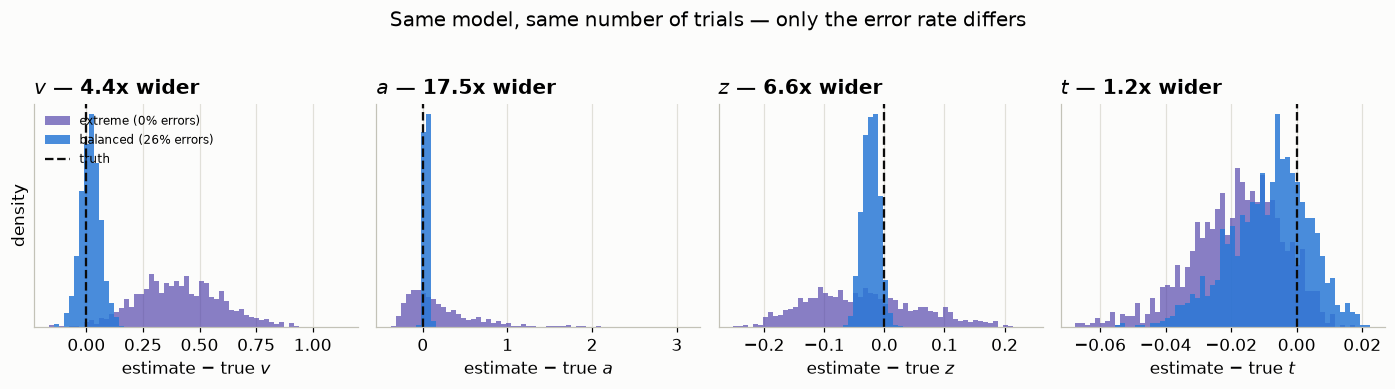

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
for ax, k in zip(axes, PARAMS):
    # Centre each design on ITS OWN truth, so the axis is estimation error and
    # the two designs are comparable even though true v differs between them.
    truth = {"v": None, "a": TRUE["a"], "z": TRUE["z"], "t": TRUE["t"]}[k]
    err = {lab: posteriors[lab][k] - (TRUE[f"v_{lab}"] if truth is None else truth)
           for lab in ["balanced", "extreme"]}

    lo = min(e.min() for e in err.values())
    hi = max(e.max() for e in err.values())
    bins = np.linspace(lo, hi, 60)

    ax.hist(err["extreme"], bins=bins, density=True, color=S.NAIVE, alpha=0.65,
            label=f"extreme ({error_rates['extreme']:.0%} errors)")
    ax.hist(err["balanced"], bins=bins, density=True, color=S.PRIMARY, alpha=0.85,
            label=f"balanced ({error_rates['balanced']:.0%} errors)")
    S.truth_line(ax, 0.0, axis="x")

    ratio = err["extreme"].std() / err["balanced"].std()
    ax.set(title=f"${k}$ — {ratio:.1f}x wider", xlabel=f"estimate $-$ true ${k}$",
           yticks=[])
axes[0].set_ylabel("density")
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Same model, same number of trials — only the error rate differs",
             y=1.03)
fig.tight_layout()

<details class="sbi-key" open>
<summary>🔑 <b>High accuracy is bad data for parameter estimation</b></summary>

This is the counterintuitive headline, and the damage is **targeted** rather
than uniform. Read the panel titles: `a` blows up by an order of magnitude
and `z` several-fold, while `t` is essentially untouched. Those are exactly
the parameters that a design where one boundary is never reached cannot see.
Nothing is wrong with the sampler and nothing is wrong with the model —
**the experiment did not collect the information**.

Notice that `t` is barely affected while `a` blows up. The damage is not
spread evenly.

Whether the point estimates also come out *biased* varies from dataset to
dataset, which is itself worth noticing: on a ridge, where the posterior mean
lands depends on where the prior and the little remaining information happen
to pull it. Sometimes you get lucky. You cannot tell from one fit which case
you are in — that is the problem.

</details>

### Exercise

We set the true start point to `z = 0.65`, above the midpoint. Predict what
happens to `corr(a, z)` if you push it to `0.80`, then check.

<details>
<summary>Answer</summary>

Change `TRUE["z"]` and re-run the extreme-design fit. The `a`–`z` correlation
stays strong — it is around `+0.84` to `+0.90` anywhere in this range, because
the mechanism does not depend on *which* boundary wins, only on the fact that
one of them always does.

What does change is `a` itself: the distance travelled is $a(1-z)$, so a
larger `z` means a smaller `a` reproduces the same data, and the posterior for
`a` shifts down accordingly.

The instructive part is what happens if you go the *other* way and set
`z = 0.5` with a balanced drift. Both trade-offs weaken at once, because now
both boundaries get reached and the data can see both distances. Identifiability
is a property of the **design**, not of the model.

</details>

**Next, tomorrow at 11:00:** today's difficulties came from correlation that
is roughly the same everywhere in parameter space. Hierarchical models bring a
nastier relative — curvature that *changes as you move* — where the failure
stops being inefficiency and becomes bias.